# FIFA World Cup Predictor

## Version 7 - Custom Class Weights

### Objective

Version 5 used the automatic `class_weight='balanced'`. Version 7 investigates whether
**custom** class weights - where we only change how important the Draw is - can improve draw
prediction.

### What we test

Same pipeline as Version 6 (Elo + Recent Form + difference features), same chronological
80/20 split, same feature set, and the same Random Forest:

```python
RandomForestClassifier(n_estimators=200, random_state=42)
```

Only the **class weight for the Draw (class 1)** changes, from 1.0 up to 2.0.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Model Training
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

In [2]:
df = pd.read_csv("../data/raw/results.csv")

print(df.shape)
df.head()

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
# Drop the 64 future World Cup fixtures that have no score yet
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(df.shape)

df.isnull().sum()

(49413, 9)


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [5]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 2      # Home Win
    elif row['home_score'] < row['away_score']:
        return 0      # Away Win
    else:
        return 1      # Draw

In [6]:
df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

result
2    24216
0    13961
1    11236
Name: count, dtype: int64

In [7]:
df['neutral_encoded'] = df['neutral'].astype(int)

# Step 1 - Build Elo Ratings (unchanged from Versions 3-6)

Exactly the same Elo code as before:

- Every team starts at 1500.
- After each match, both ratings are updated (K-factor = 20).
- We save each team's rating **BEFORE** the match, so the model never sees the future.

The dataframe stays sorted by date - this matters for the chronological split.

In [8]:
teams = pd.concat([
    df['home_team'],
    df['away_team']
    ]).unique()

elo_rating = {
    team:1500
    for team in teams
    }

In [9]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [10]:
home_elos = []
away_elos = []

In [11]:
# Work through the matches in chronological order
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

In [12]:
for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    home_elo = elo_rating[home_team]
    away_elo = elo_rating[away_team]

    # Save Elo BEFORE the match
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Expected results
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)

    # Actual result
    if row['result'] == 2:      # Home win
        actual_home = 1
        actual_away = 0

    elif row['result'] == 0:    # Away win
        actual_home = 0
        actual_away = 1

    else:                       # Draw
        actual_home = 0.5
        actual_away = 0.5

    # Update ratings
    elo_rating[home_team] = update_elo(
        home_elo,
        expected_home,
        actual_home
    )

    elo_rating[away_team] = update_elo(
        away_elo,
        expected_away,
        actual_away
    )

In [13]:
df['home_elo'] = home_elos
df['away_elo'] = away_elos

df['elo_difference'] = df['home_elo'] - df['away_elo']

# Step 2 - Build Recent Form Features (unchanged from Versions 3-6)

Exactly the same recent-form code as before:

- Form = average points from a team's last 5 matches (Win = 1.0, Draw = 0.5, Loss = 0.0).
- Form is computed from matches **BEFORE** the current match (no leakage).

In [14]:
# How many recent matches to look back
FORM_WINDOW = 5

# Each team's recent results, stored as points (oldest first)
team_form_history = {team: [] for team in teams}

home_forms = []
away_forms = []

for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    # 1) Form from matches BEFORE this one (no leakage!)
    home_history = team_form_history[home_team]
    away_history = team_form_history[away_team]

    home_form = np.mean(home_history) if len(home_history) > 0 else 0.0
    away_form = np.mean(away_history) if len(away_history) > 0 else 0.0

    # Save form BEFORE updating the histories
    home_forms.append(home_form)
    away_forms.append(away_form)

    # 2) Points for the current match
    if row['result'] == 2:      # Home win
        home_points = 1.0
        away_points = 0.0

    elif row['result'] == 0:    # Away win
        home_points = 0.0
        away_points = 1.0

    else:                       # Draw
        home_points = 0.5
        away_points = 0.5

    # 3) NOW update each team's history with the current result
    home_history.append(home_points)
    away_history.append(away_points)

    # Keep only the last 5 matches
    if len(home_history) > FORM_WINDOW:
        home_history.pop(0)
    if len(away_history) > FORM_WINDOW:
        away_history.pop(0)

In [15]:
df['home_form'] = home_forms
df['away_form'] = away_forms

# Step 3 - Difference Features (unchanged from Version 6)

We keep the difference features from Version 6.

```text
elo_difference      = home_elo - away_elo
abs_elo_difference  = |home_elo - away_elo|
form_difference     = home_form - away_form
```

In [16]:
df['abs_elo_difference'] = (df['home_elo'] - df['away_elo']).abs()
df['form_difference'] = df['home_form'] - df['away_form']

# Step 4 - Chronological Train/Test Split

Same as Versions 4-6: the dataframe is already sorted by date, so we take the **oldest 80%**
as training and the **newest 20%** as testing.

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

In [17]:
# Split the chronological dataframe: oldest 80% -> train, newest 20% -> test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Training matches:    ", len(train))
print("Testing matches:     ", len(test))
print()
print("Training period:     ", train['date'].min().date(), "to", train['date'].max().date())
print("Testing period:      ", test['date'].min().date(), "to", test['date'].max().date())

Training matches:     39530
Testing matches:      9883

Training period:      1872-11-30 to 2016-03-25
Testing period:       2016-03-25 to 2026-06-13


In [18]:
feature_cols = [
    'home_elo',
    'away_elo',
    'elo_difference',
    'home_form',
    'away_form',
    'neutral_encoded',
    'abs_elo_difference',
    'form_difference'
]

X_train = train[feature_cols]
y_train = train['result']

X_test = test[feature_cols]
y_test = test['result']

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print()
print("Test set outcome counts (the class imbalance):")
print(y_test.value_counts())

X_train shape: (39530, 8)
X_test shape:  (9883, 8)

Test set outcome counts (the class imbalance):
result
2    4708
0    2871
1    2304
Name: count, dtype: int64


# Step 5 - What is a custom class_weight?

In Version 5 we let scikit-learn choose the weights automatically with
`class_weight='balanced'`. Here we set the weights ourselves.

By default, the Random Forest counts every error the same:
getting a Draw wrong counts the same as getting a Home Win wrong.

`class_weight` is a **dial**. If we increase the weight of class 1 (Draw), then a mistake on an
actual Draw is treated as MORE serious, so the model tries harder to predict draws.

For example, `{0: 1.0, 1: 2.0, 2: 1.0}` means:

```text
Away Win errors count 1.0  (normal)
Draw errors count 2.0      (twice as important)
Home Win errors count 1.0  (normal)
```

### Why custom weights instead of `balanced`?

`balanced` picks ONE weight automatically. Custom weights let us explore how sensitive the
model is to the Draw, and find the level we like. This is a controlled experiment on a single
idea: "does making Draws 1.25x, 1.5x, ..., 2.0x more important improve draw prediction?"

# Step 6 - The Configurations We Test

Everything stays the same except the Draw (class 1) weight. We compare five settings:

| Draw weight | class_weight | Meaning |
|------------:|--------------|---------|
| 1.00 | {0:1.0, 1:1.0, 2:1.0} | Baseline - draws not special |
| 1.25 | {0:1.0, 1:1.25, 2:1.0} | Draws a bit more important |
| 1.50 | {0:1.0, 1:1.5, 2:1.0} | Draws more important |
| 1.75 | {0:1.0, 1:1.75, 2:1.0} | Draws much more important |
| 2.00 | {0:1.0, 1:2.0, 2:1.0} | Draws twice as important |

In [19]:
draw_weights = [1.0, 1.25, 1.5, 1.75, 2.0]

results = []
models = {}

for w in draw_weights:
    cw = {0: 1.0, 1: w, 2: 1.0}

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight=cw
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, labels=[0, 1, 2], average=None
    )
    macro_f1 = np.mean(f)

    results.append({
        'Draw weight': w,
        'Accuracy': acc,
        'Draw precision': p[1],
        'Draw recall': r[1],
        'Draw F1': f[1],
        'Macro-F1': macro_f1,
    })

    models[w] = (model, pred)

print("All five models trained and evaluated.")

All five models trained and evaluated.


In [20]:
summary = pd.DataFrame(results)

summary.round(4)

,Draw weight,Accuracy,Draw precision,Draw recall,Draw F1,Macro-F1
0,1.00,0.5617,0.2851,0.1250,0.1738,0.4686
1,1.25,0.5524,0.2723,0.1593,0.2010,0.4722
2,1.50,0.5460,0.2724,0.1871,0.2218,0.4746
3,1.75,0.5428,0.2741,0.2157,0.2414,0.4786
4,2.00,0.5412,0.2739,0.2391,0.2553,0.4817


# Step 7 - Full Classification Reports

Here is the complete report for every configuration. Classes: 0 = Away Win, 1 = Draw, 2 = Home Win.

Watch how Draw (class 1) recall grows as the weight increases.

In [21]:
for w in draw_weights:
    pred = models[w][1]
    print(f"===== class_weight={{0:1.0, 1:{w}, 2:1.0}} ===")
    print(classification_report(y_test, pred))
    print()

===== class_weight={0:1.0, 1:1.0, 2:1.0} ===
              precision    recall  f1-score   support

           0       0.55      0.53      0.54      2871
           1       0.29      0.12      0.17      2304
           2       0.61      0.79      0.69      4708

    accuracy                           0.56      9883
   macro avg       0.48      0.48      0.47      9883
weighted avg       0.52      0.56      0.53      9883


===== class_weight={0:1.0, 1:1.25, 2:1.0} ===
              precision    recall  f1-score   support

           0       0.56      0.51      0.53      2871
           1       0.27      0.16      0.20      2304
           2       0.61      0.77      0.68      4708

    accuracy                           0.55      9883
   macro avg       0.48      0.48      0.47      9883
weighted avg       0.52      0.55      0.53      9883


===== class_weight={0:1.0, 1:1.5, 2:1.0} ===
              precision    recall  f1-score   support

           0       0.56      0.49      0.52  

# Step 8 - Visualising the Trade-off

The chart below shows how accuracy, Draw recall, Draw F1 and macro-F1 change as the Draw
weight rises. Notice accuracy slowly falls while the draw metrics climb.

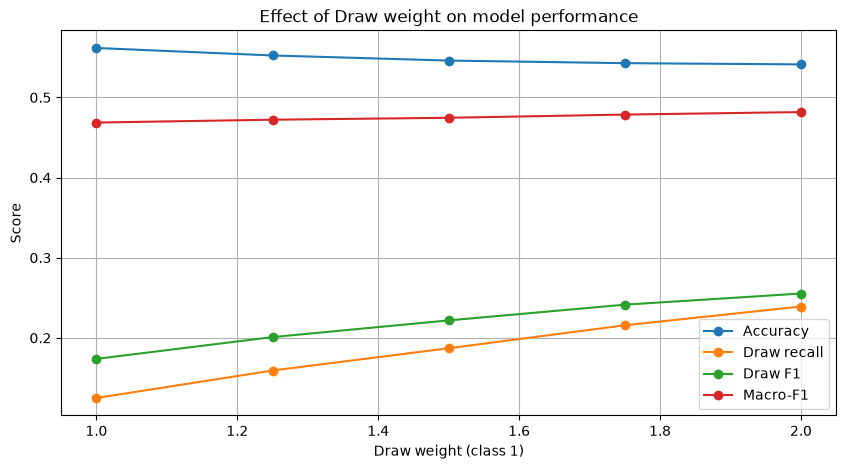

In [22]:
%matplotlib inline

plt.figure(figsize=(10, 5))
plt.plot(summary['Draw weight'], summary['Accuracy'], marker='o', label='Accuracy')
plt.plot(summary['Draw weight'], summary['Draw recall'], marker='o', label='Draw recall')
plt.plot(summary['Draw weight'], summary['Draw F1'], marker='o', label='Draw F1')
plt.plot(summary['Draw weight'], summary['Macro-F1'], marker='o', label='Macro-F1')
plt.xlabel('Draw weight (class 1)')
plt.ylabel('Score')
plt.title('Effect of Draw weight on model performance')
plt.legend()
plt.grid(True)
plt.show()

# Summary - Which Class Weight Is Best?

| Draw weight | Accuracy | Draw recall | Draw F1 | Macro-F1 |
|------------:|----------|-------------|---------|----------|
| 1.00 | 56.17% | 0.125 | 0.174 | 0.469 |
| 1.25 | 55.24% | 0.159 | 0.201 | 0.472 |
| 1.50 | 54.60% | 0.187 | 0.222 | 0.475 |
| 1.75 | 54.28% | 0.216 | 0.241 | 0.479 |
| 2.00 | 54.12% | 0.239 | 0.255 | 0.482 |

### The trade-off (why we do NOT pick by accuracy alone)

Raising the Draw weight clearly trades overall accuracy for draw performance:

- Accuracy falls slowly: 56.17% -> 54.12% (only ~2 points across all five models).
- Draw recall roughly doubles: 0.125 -> 0.239.
- Draw F1 rises steadily: 0.174 -> 0.255.
- Macro-F1 (which treats every class equally) rises the whole way: 0.469 -> 0.482.

The best-accuracy model (weight 1.0) simply ignores draws, so it is **not** actually the best
for our task - it scores worst on the class we most want to improve.

### Which configuration performed best?

Among the five tested, **{0: 1.0, 1: 2.0, 2: 1.0}** is best: it achieves the highest macro-F1
(0.482), Draw F1 (0.255) and Draw recall (0.239), while keeping accuracy within about 2 points
of the default.

The sweet spot is around **1.75 - 2.0**:

- **1.75** captures most of the gain (Draw F1 0.241, macro-F1 0.479) with slightly higher accuracy.
- **2.0** pushes draw performance a little further (Draw F1 0.255, macro-F1 0.482).

Either is a reasonable choice depending on how much accuracy we can give up. Because draws are
~23% of matches and the whole point is to predict them better, we recommend **{0:1.0, 1:2.0, 2:1.0}**.